# Steane Circ Level Noise (Multi round threshold)

Data generation and analysis
+ different decoder: ML, MWPM
+ different observables: Z,X
+ different distances
+ different noise levels
+ multiple rounds

analysis: 
+ determine thresholds depended on number of rounds


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import read_config, write_config, smart_read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER

## Config Defintions and Data Generation

Steane circ (order 0p) with multiple QEC rounds (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# General parameter
expected_p_th_log = -1.7
width = 0.5
noise_rates = [float(x) for x in np.logspace(expected_p_th_log - width , expected_p_th_log + width,dtype=float)]
distances = [3,5,7,]
qec_rounds = [1,2,3,4,5,6,8,10,12,14]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
# ml
num_shots_ML = 1_000 # 20 min
decoder_type_ML = "ml"
# mwpm
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [3]:
# Folder names (for writing data to file):
w_folder_name_ML_Z = "md_mr_mp_steane_Z_ML"
w_folder_name_ML_X = "md_mr_mp_steane_X_ML"
w_folder_name_MWPM_Z = "md_mr_mp_steane_Z_MWPM"
w_folder_name_MWPM_X = "md_mr_mp_steane_X_MWPM"

In [4]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [ ]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,w_folder_name_ML_Z,backup=True)

In [ ]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_Z)

In [ ]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,w_folder_name_ML_X,backup=True)

In [ ]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_X)

In [ ]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,w_folder_name_MWPM_Z,backup=True)

In [ ]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_Z)

In [ ]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,w_folder_name_MWPM_X,backup=True)

In [ ]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_X)

# Analysis (TODO!)

In [5]:
# Folder paths (reading in data)
r_folder_name_ML_Z = "md_mr_mp_steane_Z_ML"
r_folder_name_ML_X = "md_mr_mp_steane_X_ML"
r_folder_name_MWPM_Z = "md_mr_mp_steane_Z_MWPM"
r_folder_name_MWPM_X = "md_mr_mp_steane_X_MWPM"


In [ ]:
def analysis_pipeline(
        folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None,
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: float = None,
        plots = True,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_name)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [ ]:
# General fit parameters: 
g_pth_mwpm_Z = [0.02498881, 0.02063753, 0.01898687, 0.01845835, 0.01885784, 0.01609146, 0.01686323, 0.017, 0.017, 0.017,] 
g_pth_ml_Z = g_pth_mwpm_Z 
g_pth_ml_X = [0.035] * len(qec_rounds)
g_pth_mwpm_X = [0.027] * len(qec_rounds)

g_nu = [0.04] * len(qec_rounds)

p_window = 10**(0.15)
min_distance = [3] * len(qec_rounds)


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.49581879446960997
             x: [ 2.819e-02  7.699e-01]
           nit: 73
          nfev: 138
 final_simplex: (array([[ 2.819e-02,  7.699e-01],
                       [ 2.819e-02,  7.699e-01],
                       [ 2.819e-02,  7.699e-01]]), array([ 4.958e-01,  4.958e-01,  4.958e-01]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1880973644102208
             x: [ 2.141e-02  7.225e-01]
           nit: 59
          nfev: 128
 final_simplex: (array([[ 2.141e-02,  7.225e-01],
                       [ 2.141e-02,  7.225e-01],
                       [ 2.141e-02,  7.225e-01]]), array([ 1.188e+00,  1.188e+00,  1.188e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8222493876473195
             x: [ 1.816e-02  6.793e-01]
           nit: 73
     

<Figure size 640x480 with 0 Axes>

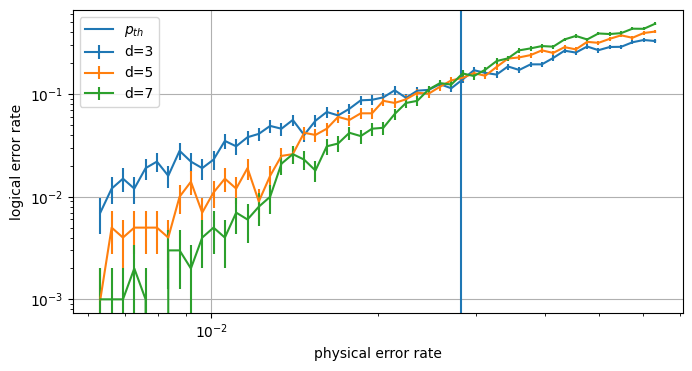

<Figure size 640x480 with 0 Axes>

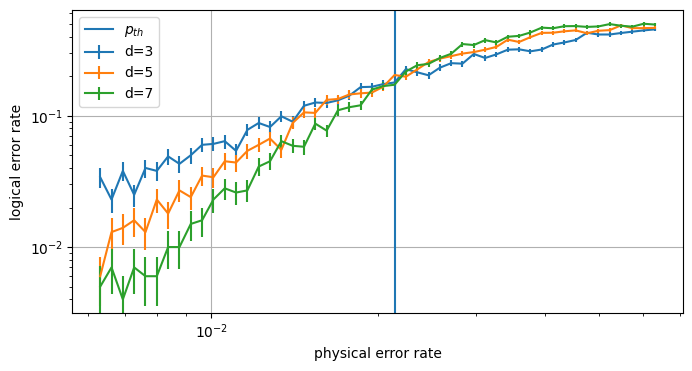

<Figure size 640x480 with 0 Axes>

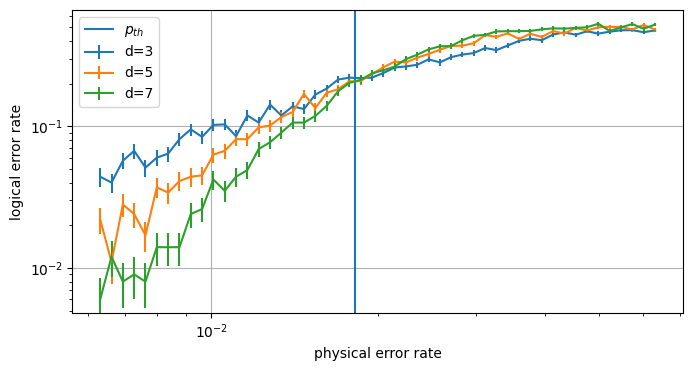

<Figure size 640x480 with 0 Axes>

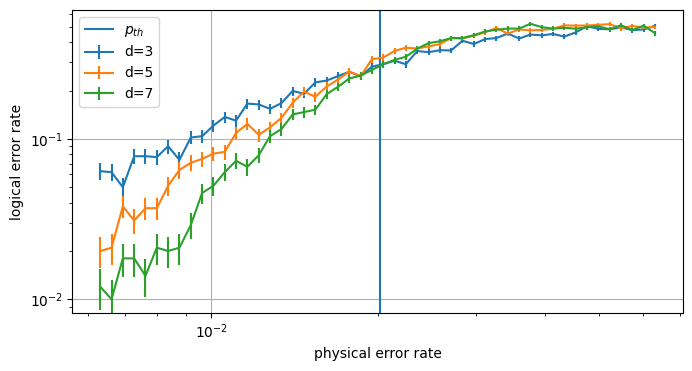

<Figure size 640x480 with 0 Axes>

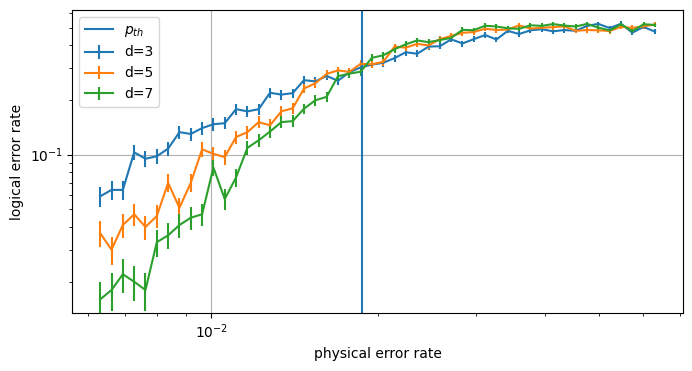

<Figure size 640x480 with 0 Axes>

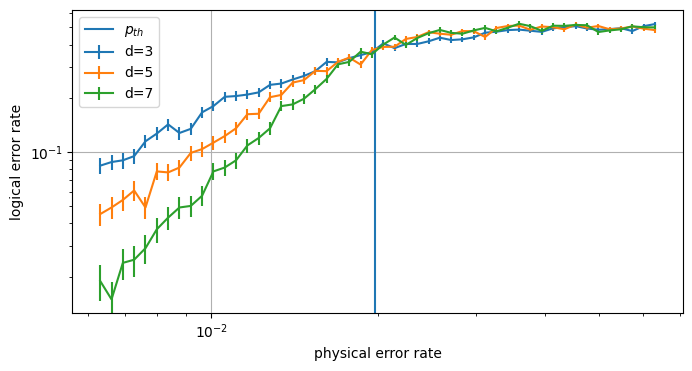

<Figure size 640x480 with 0 Axes>

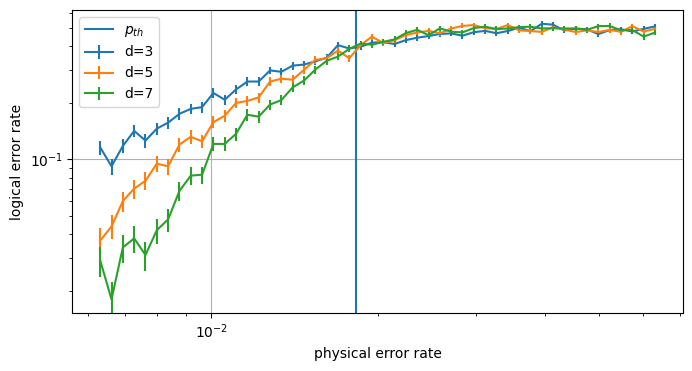

<Figure size 640x480 with 0 Axes>

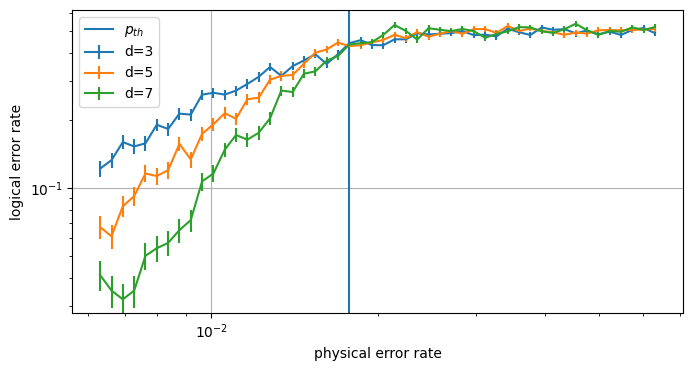

<Figure size 640x480 with 0 Axes>

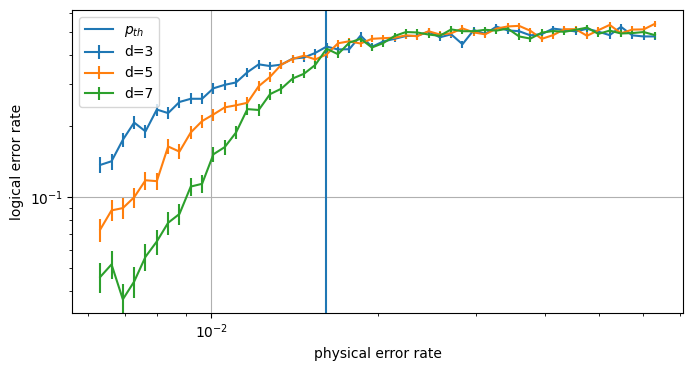

<Figure size 640x480 with 0 Axes>

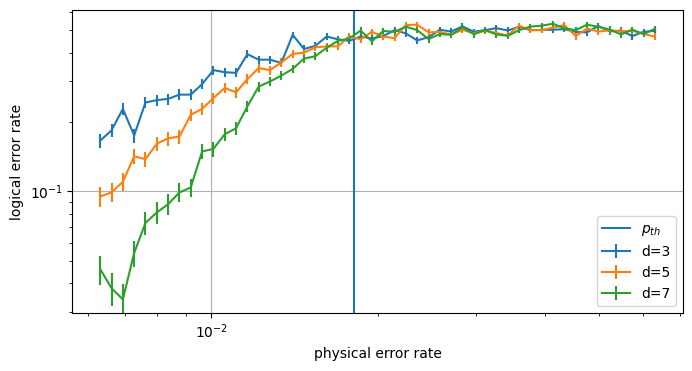

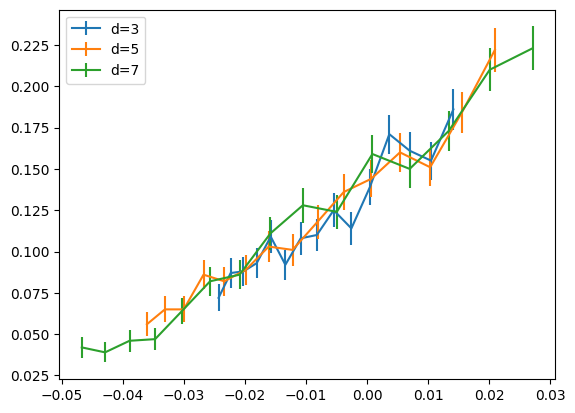

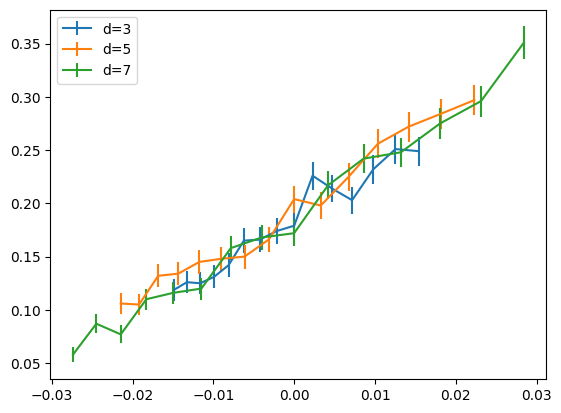

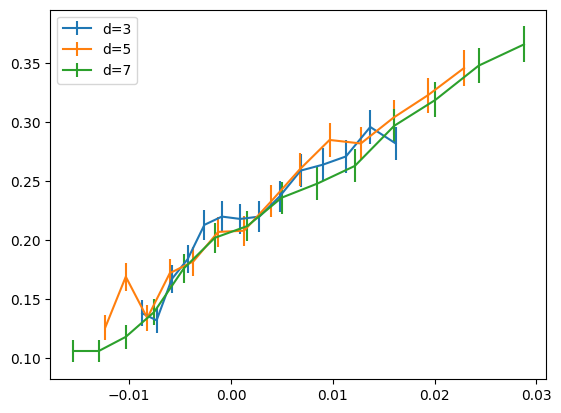

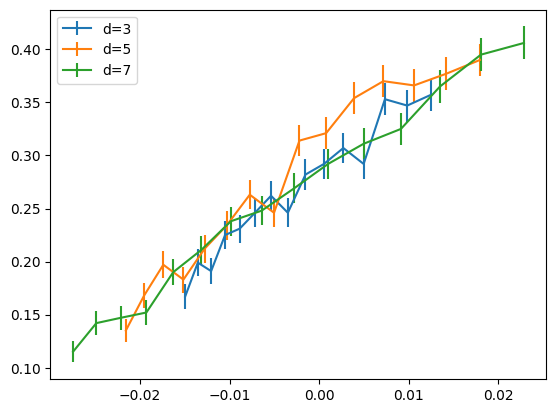

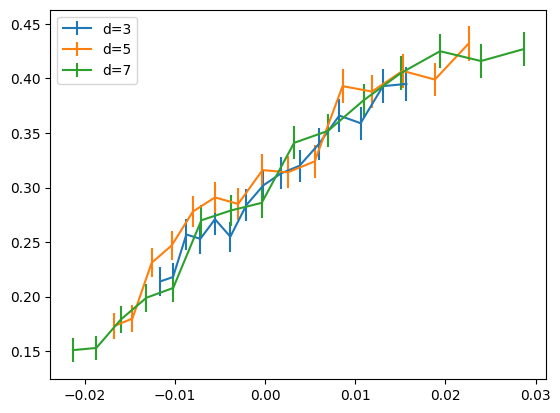

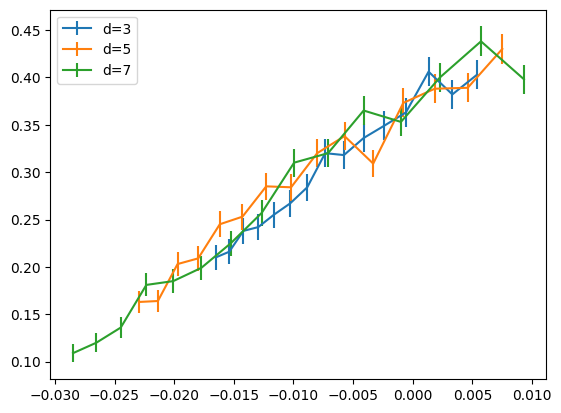

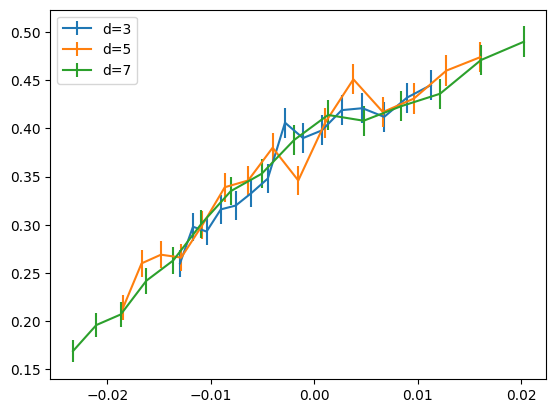

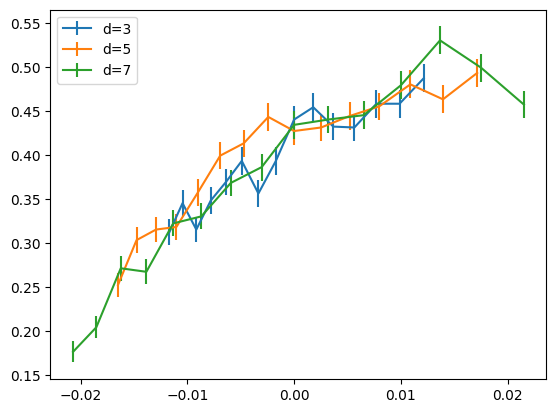

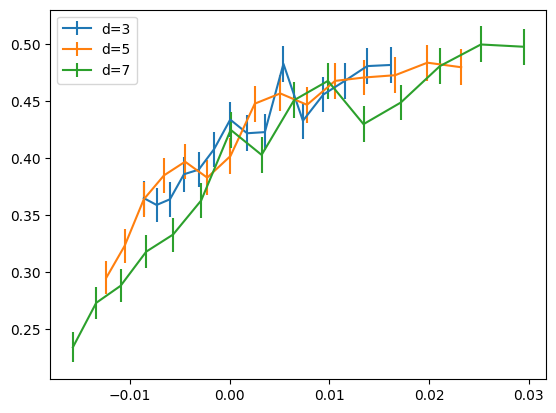

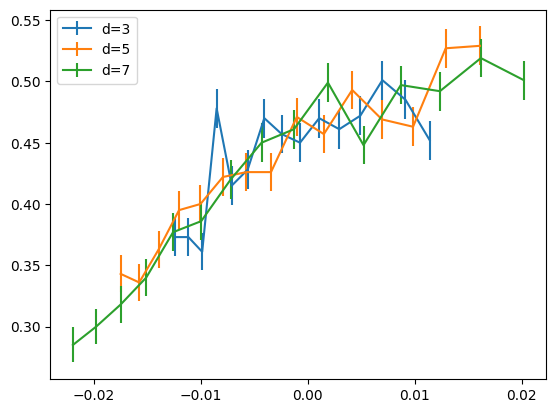

<Figure size 640x480 with 0 Axes>

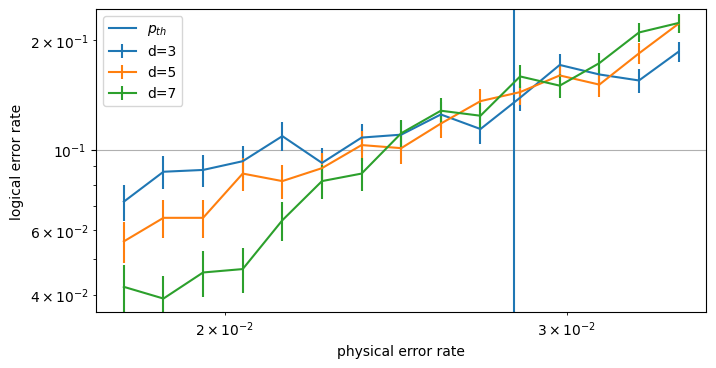

<Figure size 640x480 with 0 Axes>

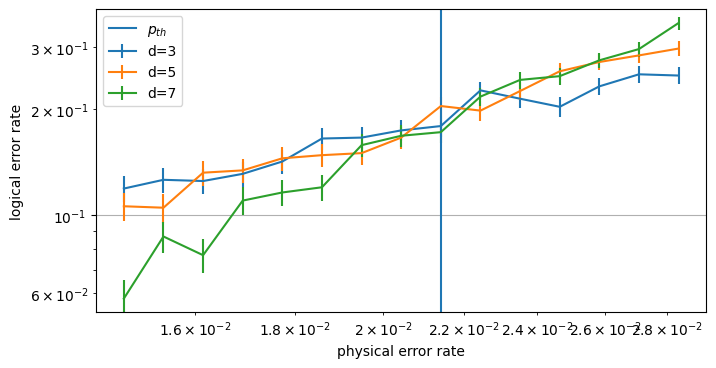

<Figure size 640x480 with 0 Axes>

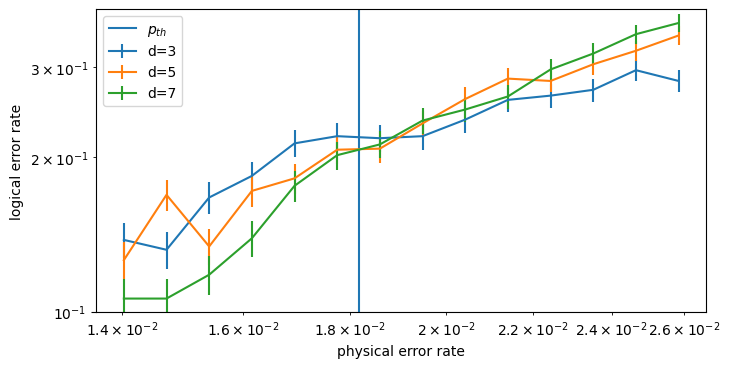

<Figure size 640x480 with 0 Axes>

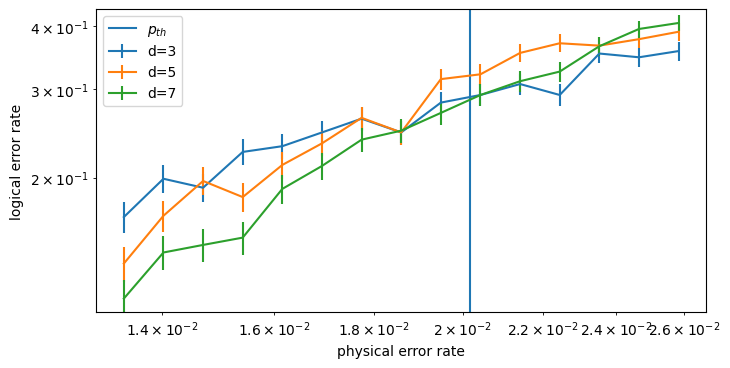

<Figure size 640x480 with 0 Axes>

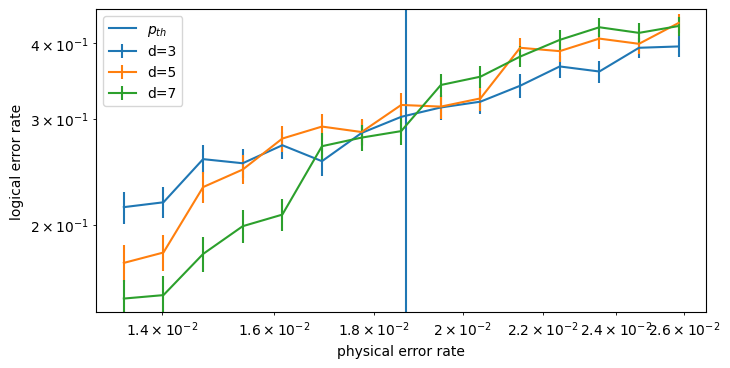

<Figure size 640x480 with 0 Axes>

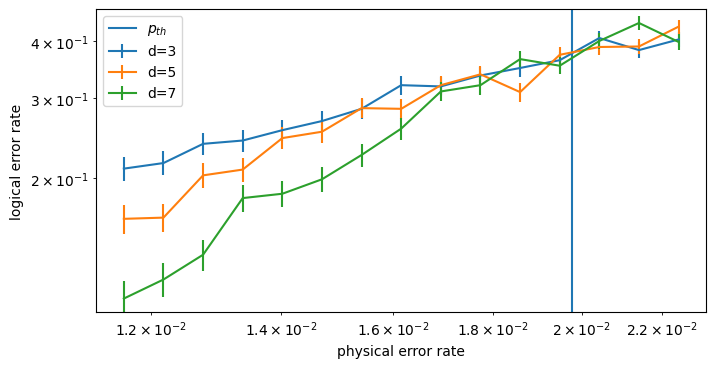

<Figure size 640x480 with 0 Axes>

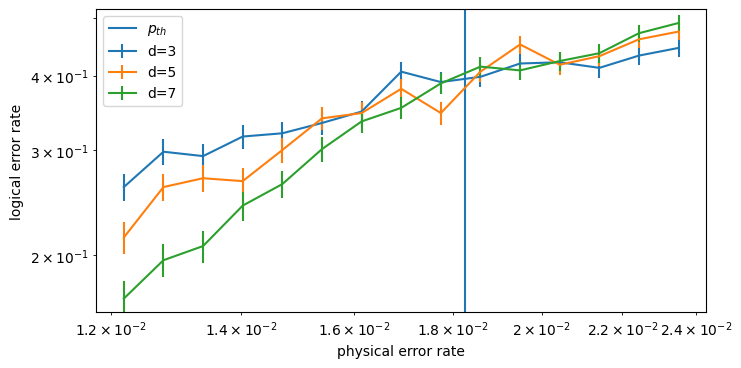

<Figure size 640x480 with 0 Axes>

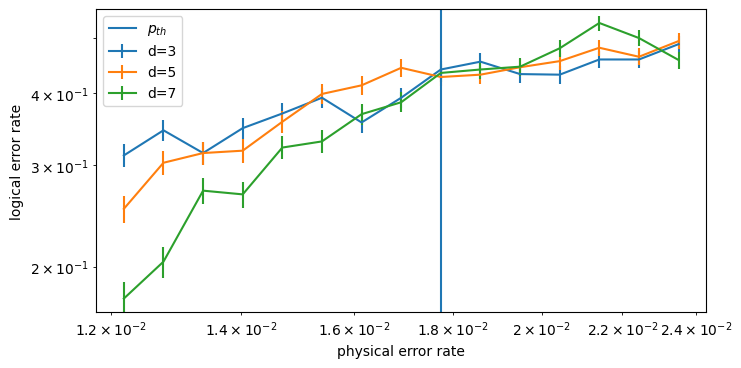

<Figure size 640x480 with 0 Axes>

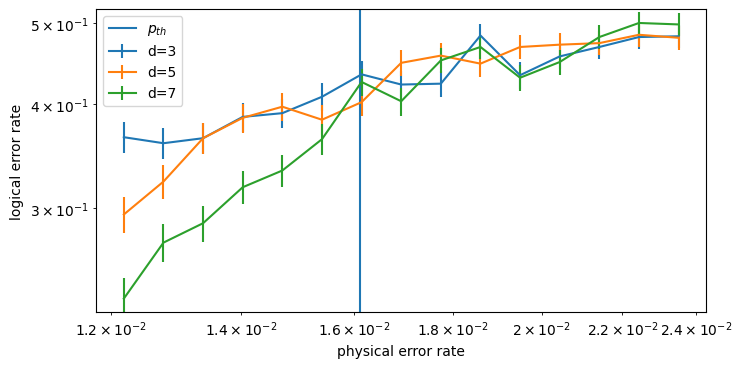

<Figure size 640x480 with 0 Axes>

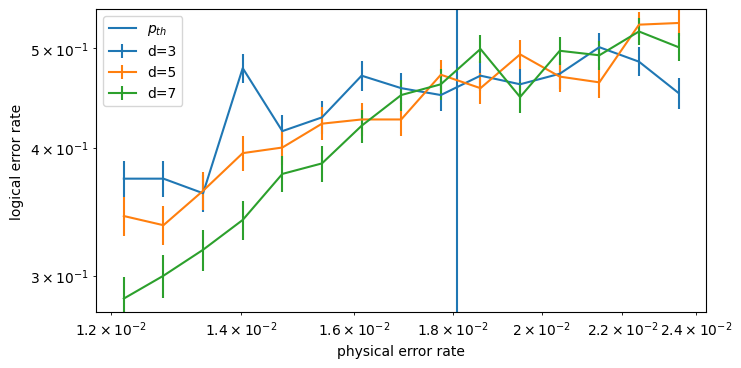

[0.02819314 0.0214137  0.01816271 0.02017927 0.0186905  0.01977337
 0.01824629 0.01774106 0.01612276 0.01808923]
[1.29882025 1.38408246 1.47211754 1.39311775 1.39949401 1.55543627
 1.44536542 1.48004749 1.40616    1.48120882]


In [10]:
folder_name = r_folder_name_ML_Z
g_pth = g_pth_ml_Z

result = analysis_pipeline(
    folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result

In [ ]:
folder_name = r_folder_name_ML_X 
g_pth = g_pth_ml_X

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result

In [ ]:
folder_name = r_folder_name_MWPM_Z 
g_pth = g_pth_mwpm_Z

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result

In [ ]:
folder_name = r_folder_name_MWPM_X 
g_pth = g_pth_mwpm_X 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

## Results

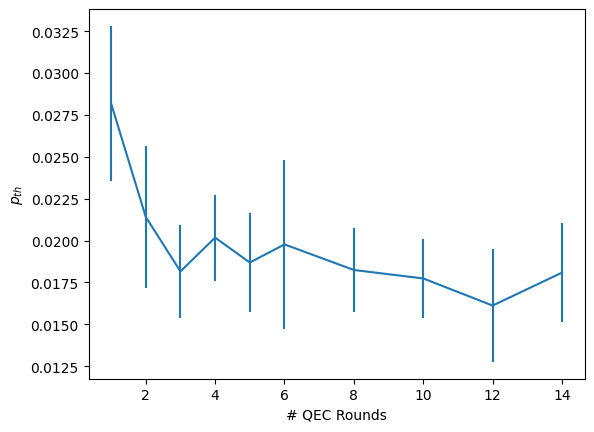

In [11]:
results = results_ML_Z 
p_th = results["p_th"]
err_p_th = results["err_p_th"]

plt.figure()
plt.errorbar(qec_rounds, p_th, yerr=err_p_th)
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.show()


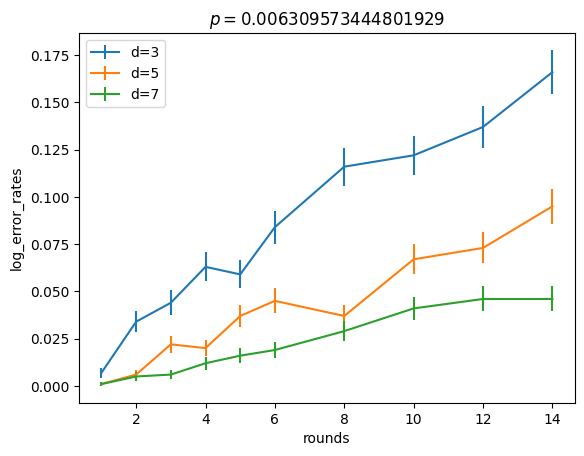

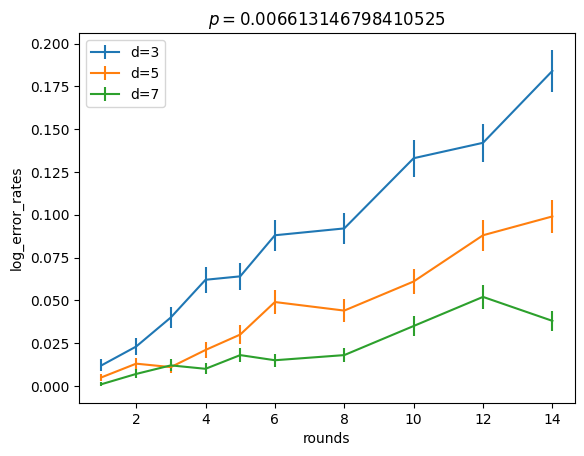

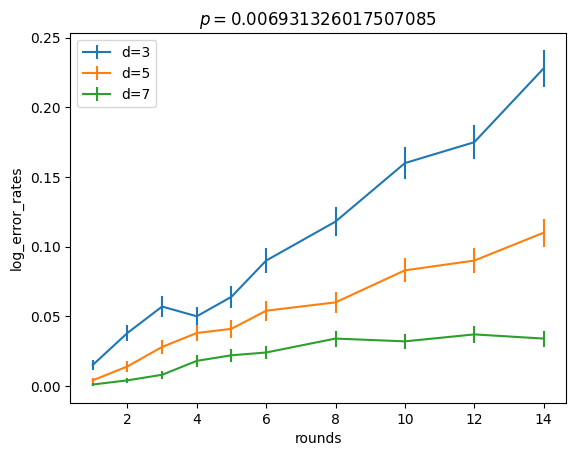

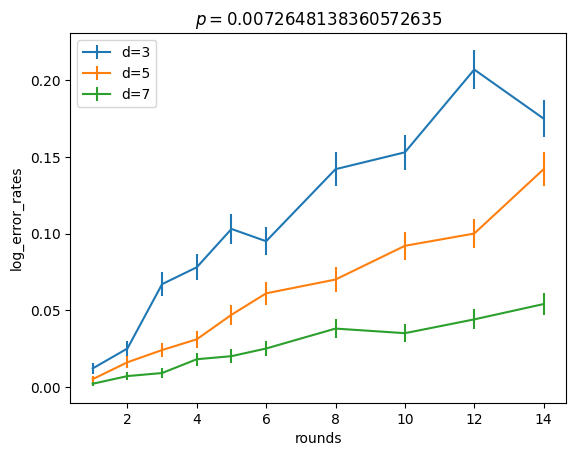

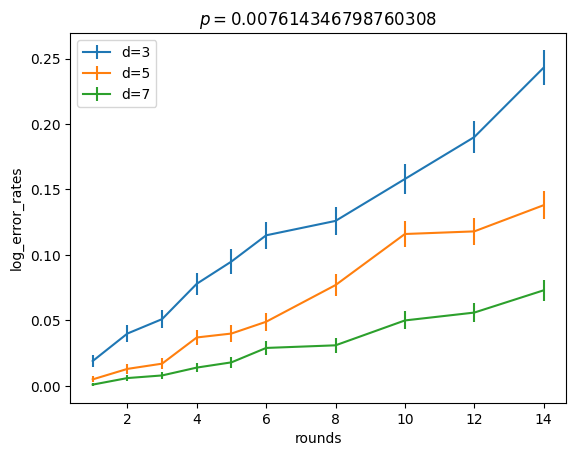

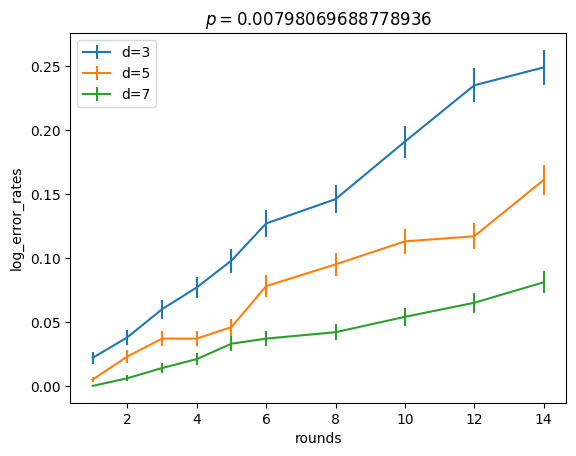

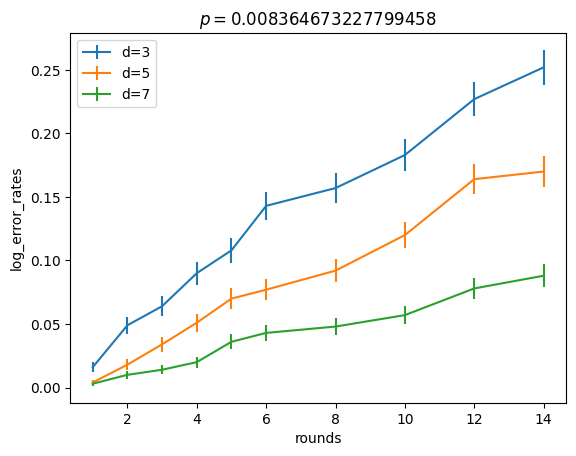

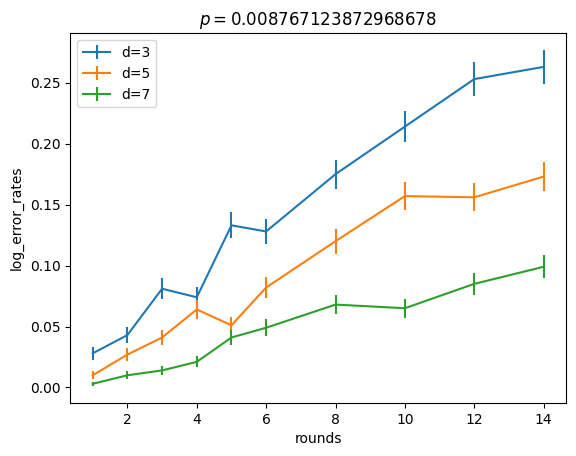

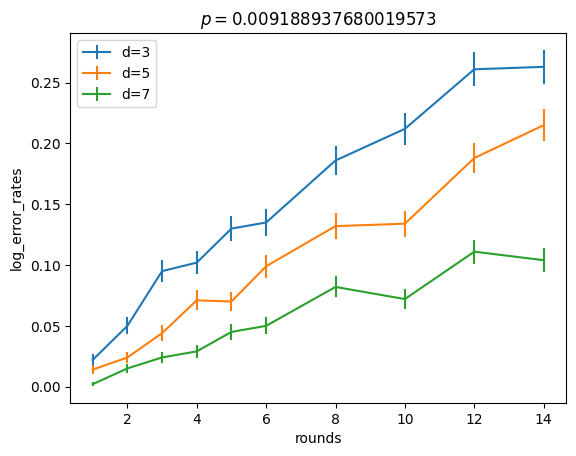

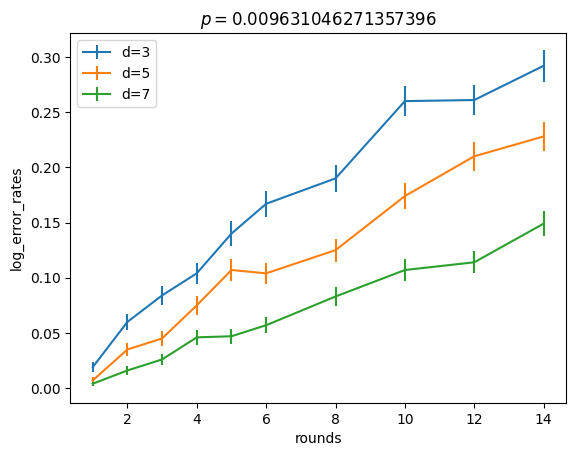

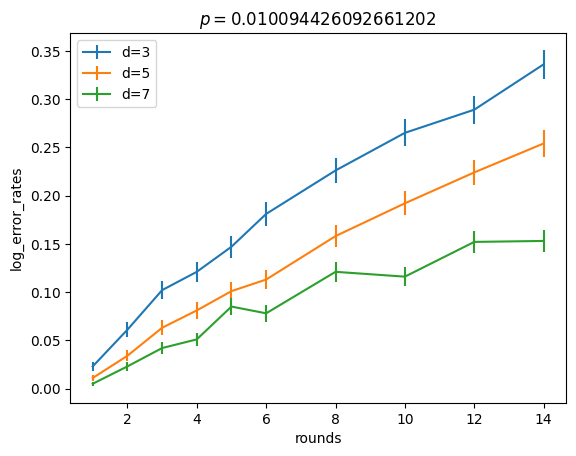

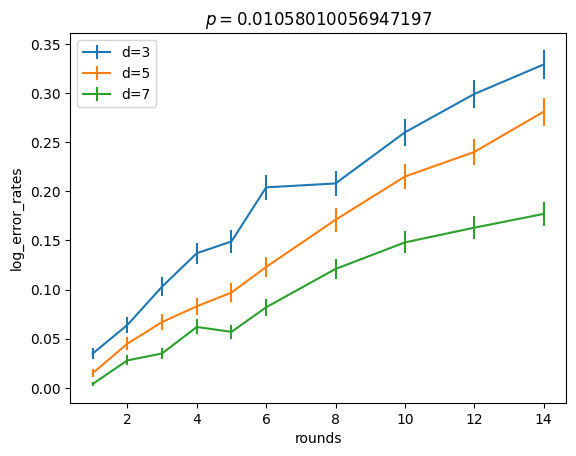

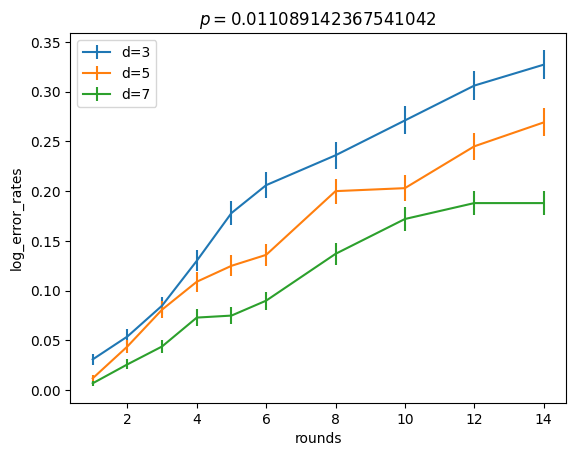

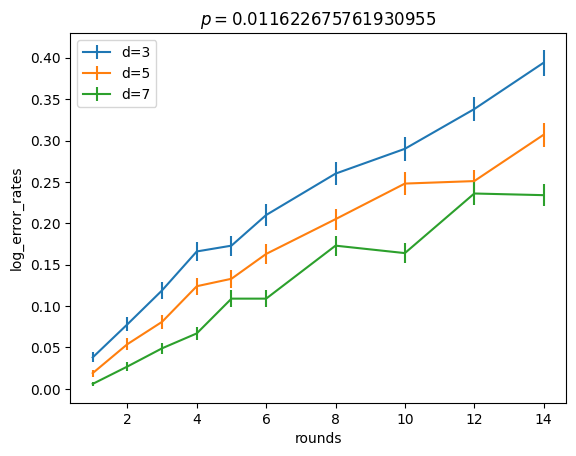

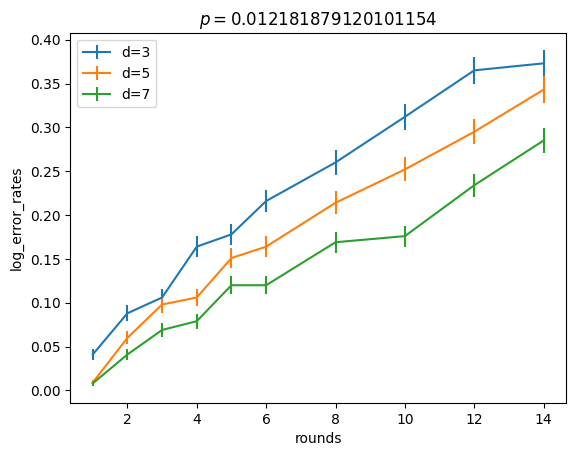

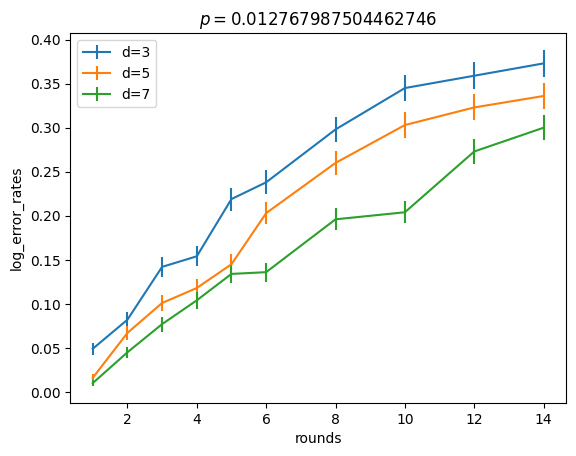

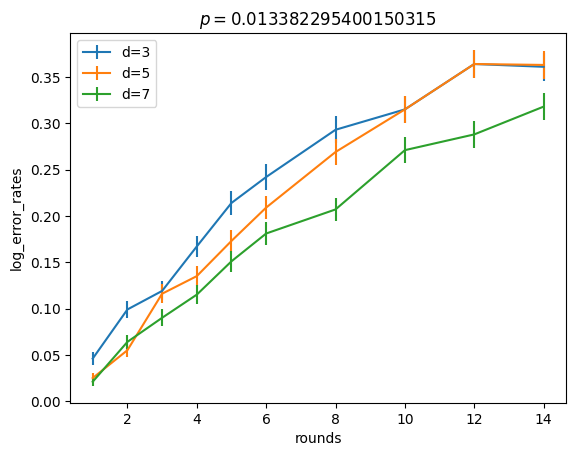

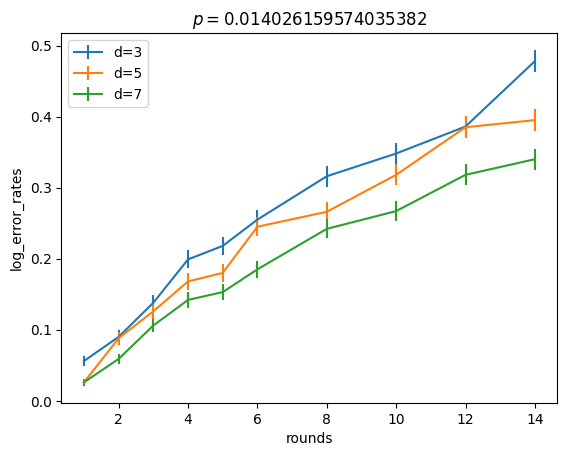

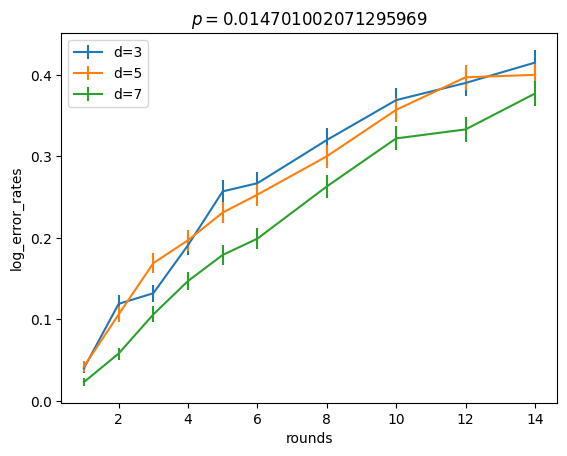

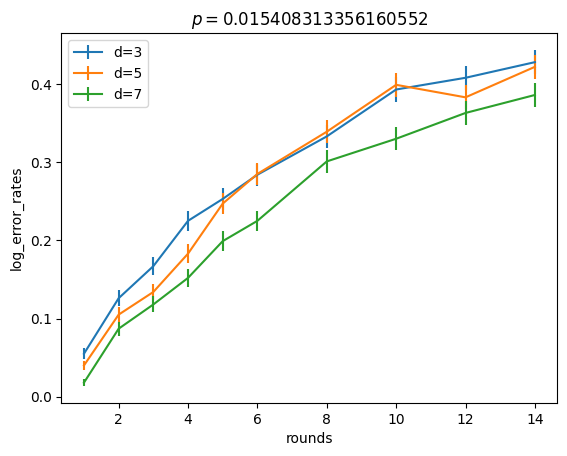

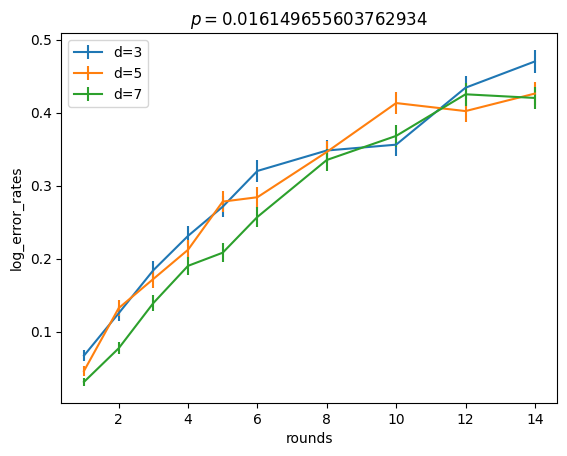

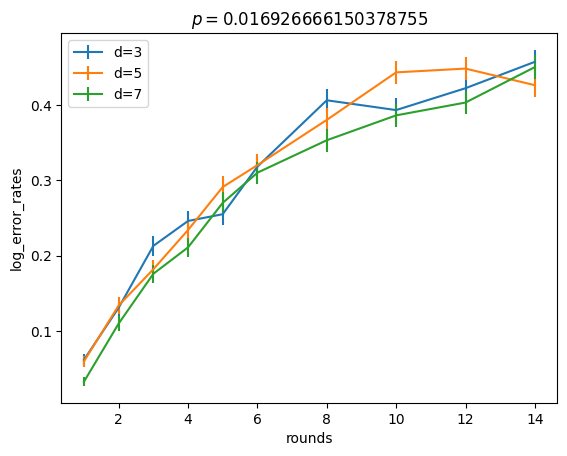

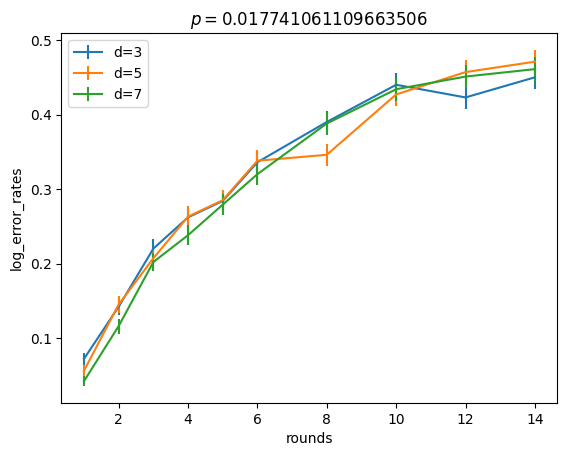

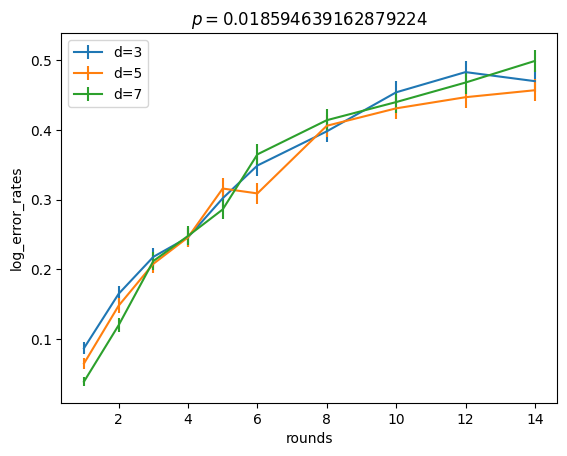

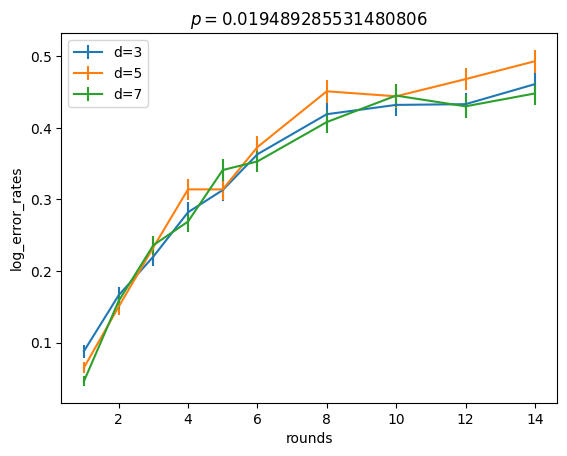

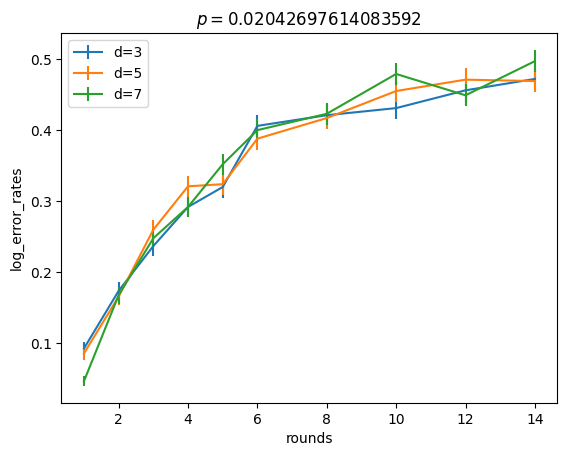

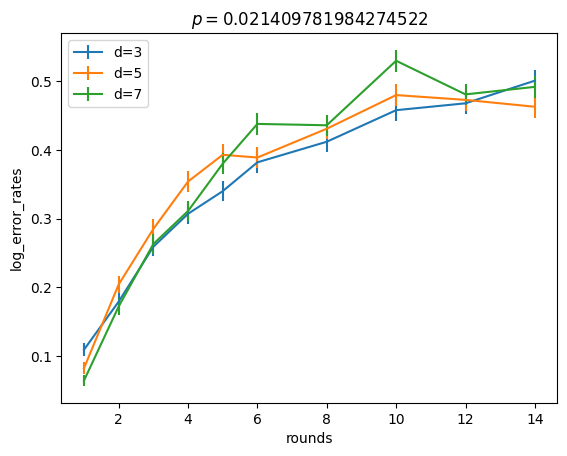

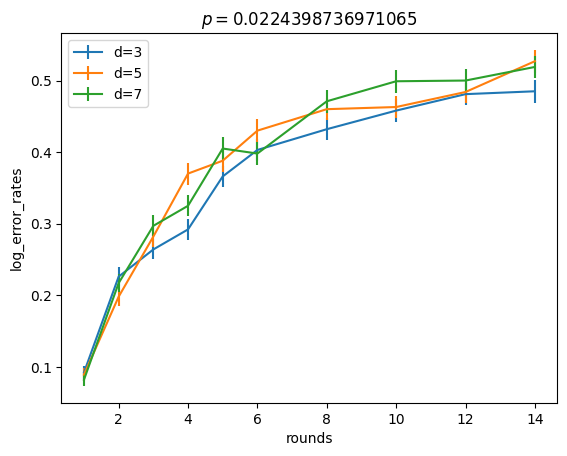

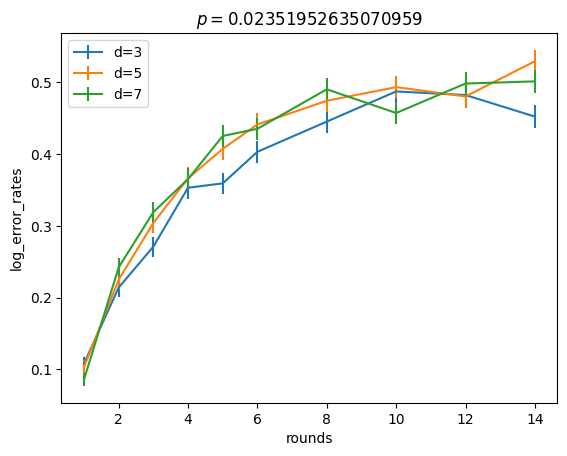

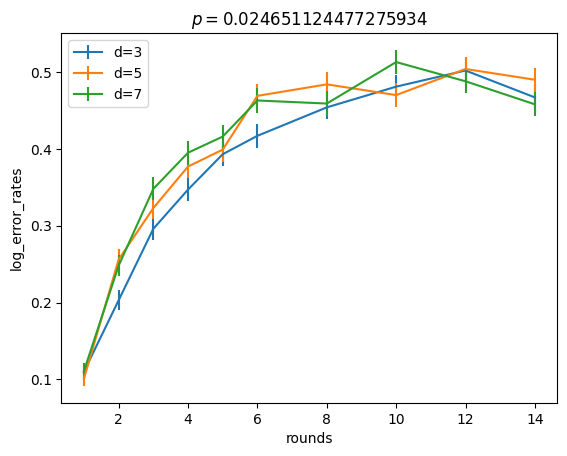

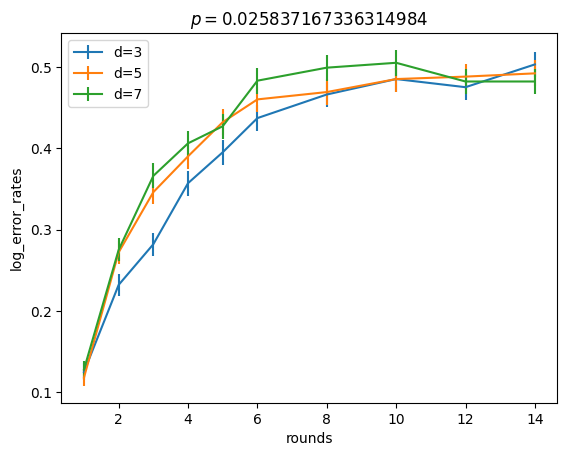

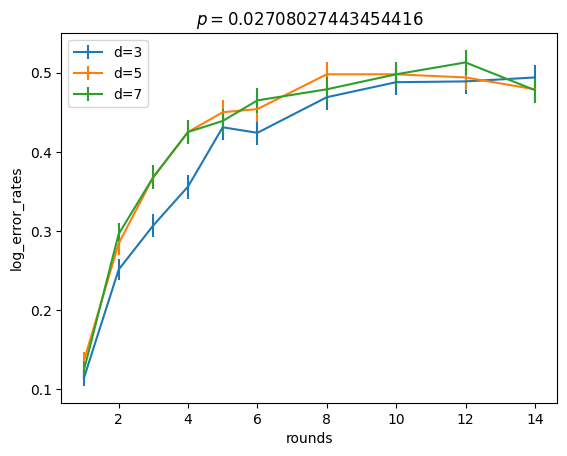

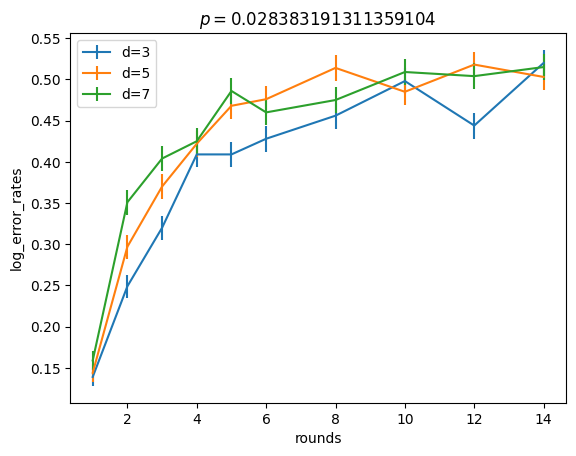

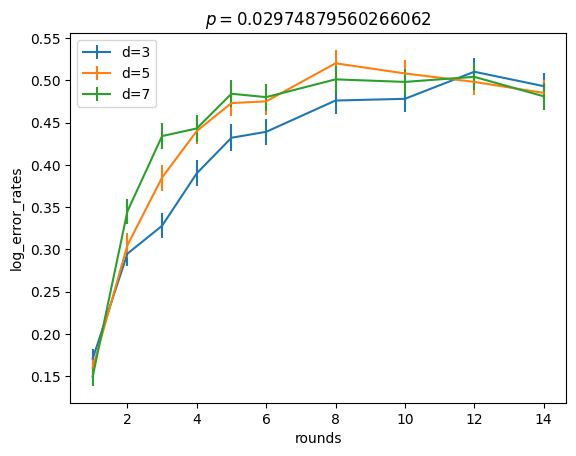

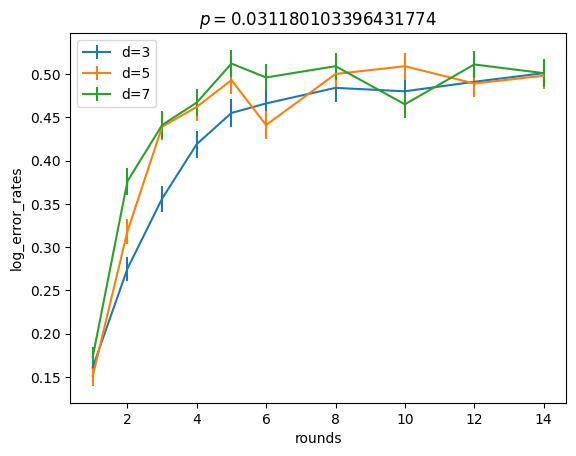

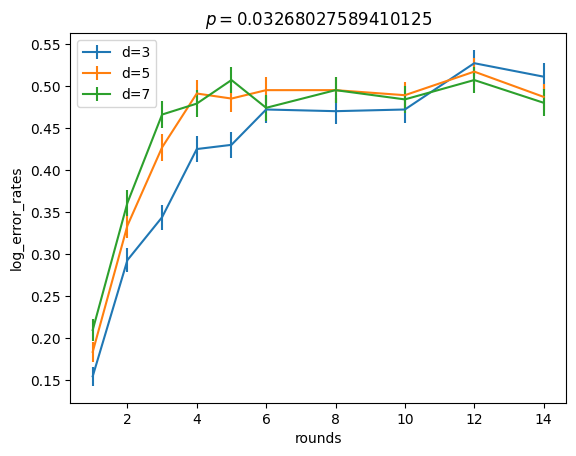

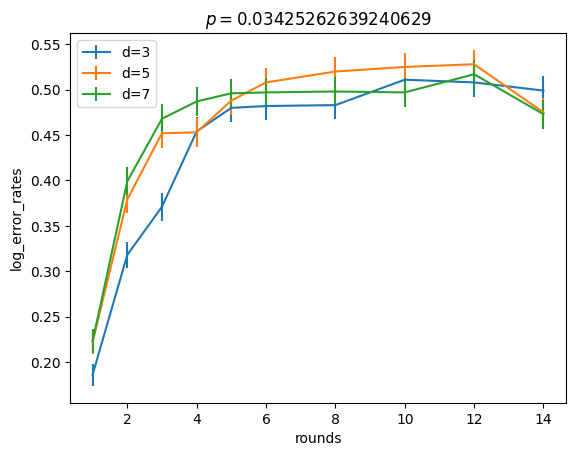

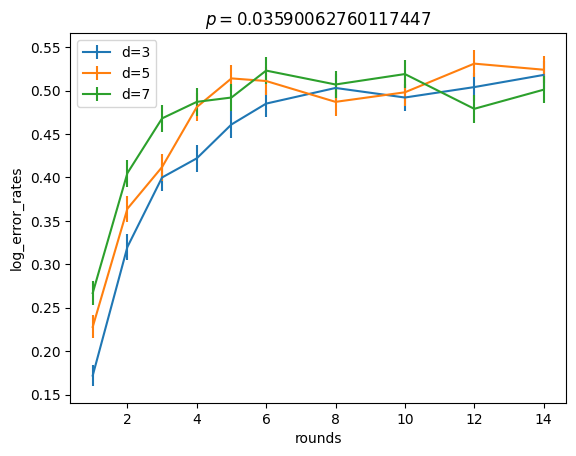

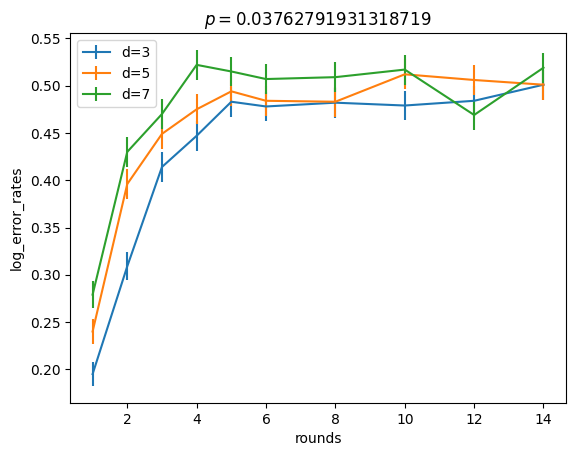

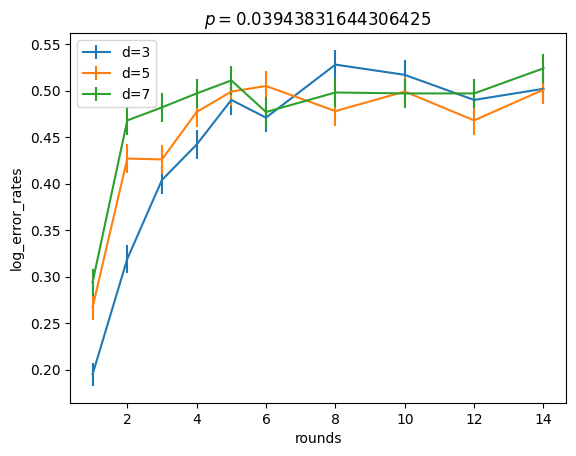

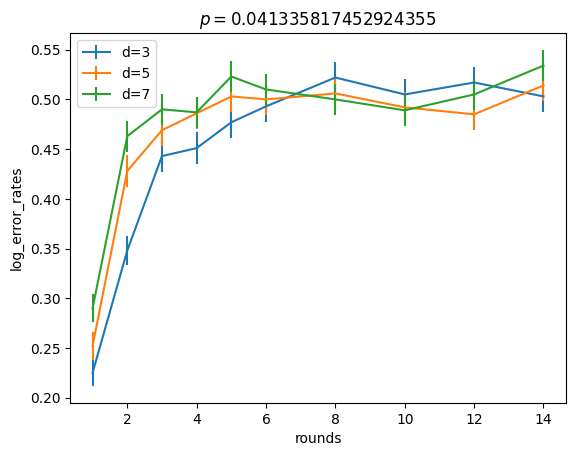

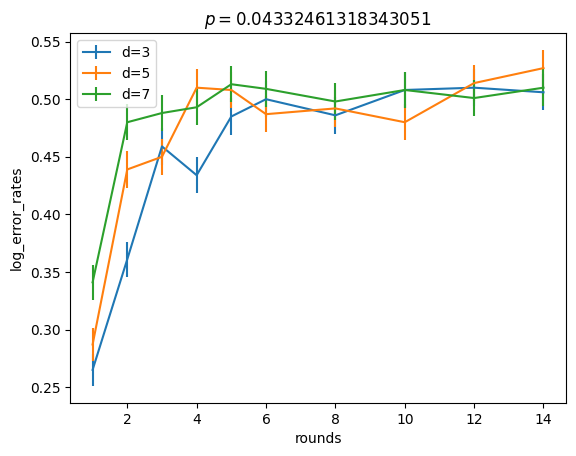

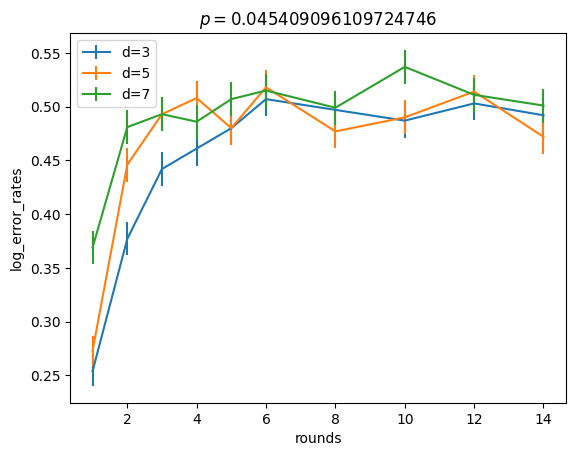

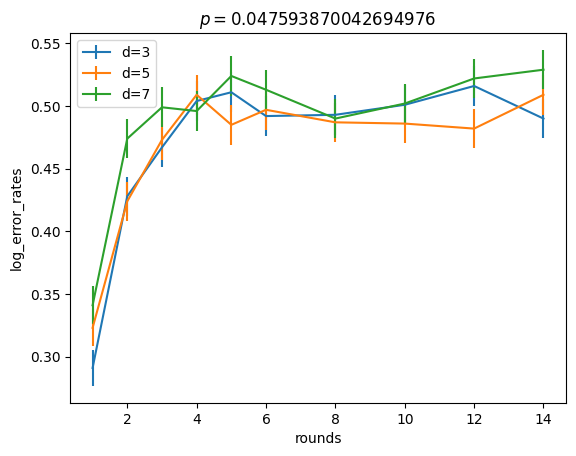

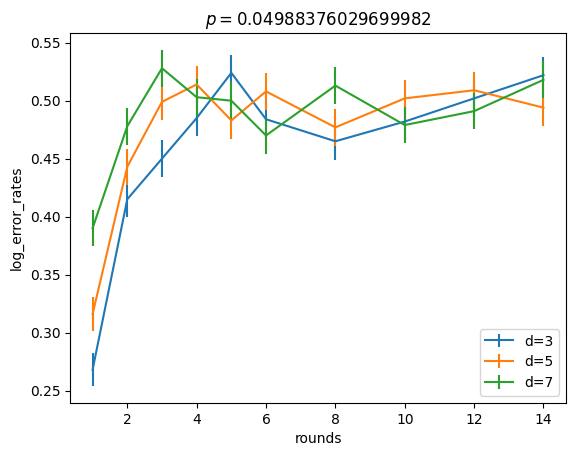

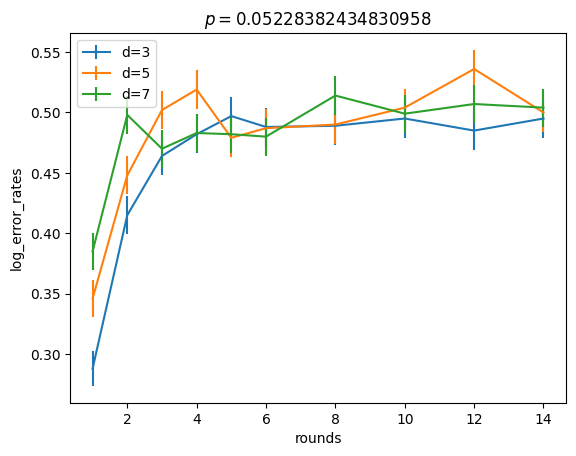

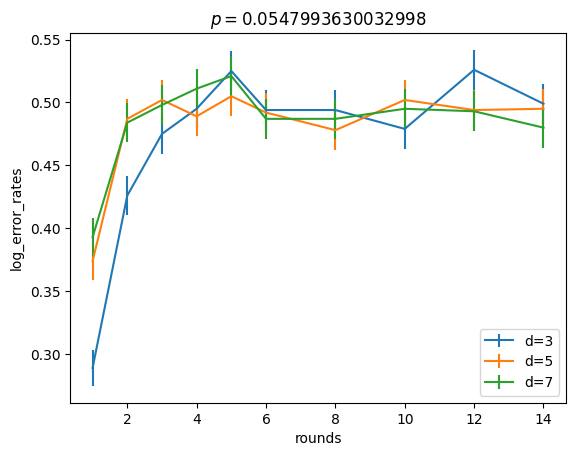

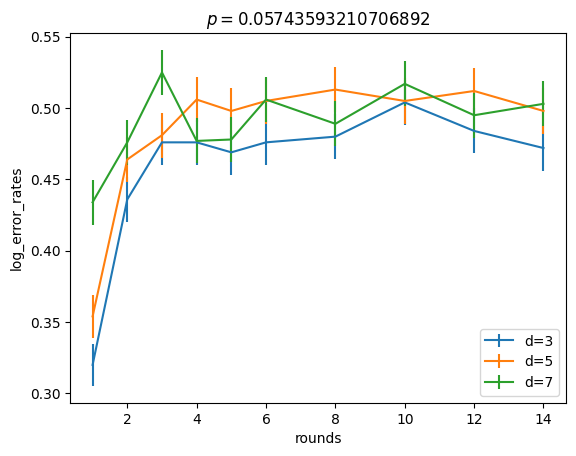

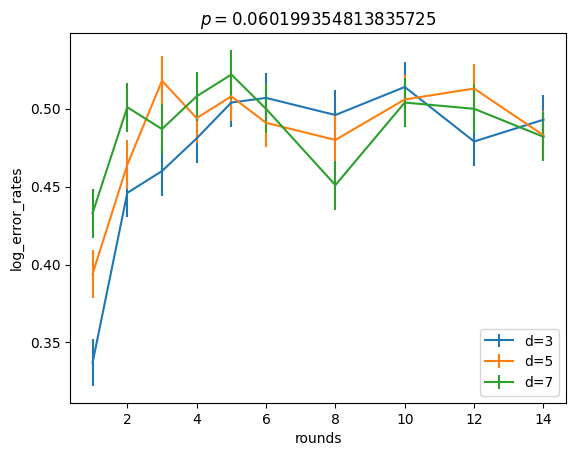

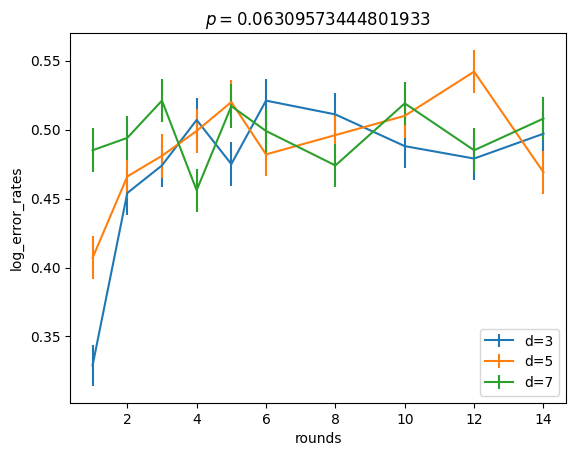

In [12]:
distances = results["distances"]
rounds = results["rounds"]
log_error_rates = results["log_error_rates"]
err_log_error_rates = results["err_log_error_rates"]

for i_noise_rate in range(len(results["noise_rates"])):
    plt.figure()
    plt.title(f"$p={results["noise_rates"][i_noise_rate]}$")
    for i in range(len(distances)):
        plt.errorbar(
            rounds,
            log_error_rates[i,:,i_noise_rate],
            yerr=err_log_error_rates[i,:,i_noise_rate], 
            label=f"d={distances[i]}",
            )
    
    plt.legend()
    plt.xlabel("rounds")
    plt.ylabel("log_error_rates")
    plt.show()
